# The warp-centering issue

### The question

Group registration produces J warps γ_i and registered observations y_i∘γ_i. The registered
observations live on the time axis of the **template**, but the template's own timing is
arbitrary: it depends on which observation seeded the iteration, on the method, and on the
initial cross-sectional mean. Any common warp η can be applied to all γ_i (γ_i ↦ γ_i∘η) without
changing the *relative* alignment of the observations; it only changes the time axis on which
the registered data and the template are reported.

**Centering** picks one representative from this family: the warps are composed with the inverse
of their Karcher mean, γ_i ↦ γ_i∘γ̄⁻¹, so that the Karcher mean of the centered warps is the
identity. The registered data then keep the *average timing of the original data*, which is
the natural convention when the goal is to describe timing differences between observations or
groups (the displacement fields are then deviations from the group-average timing).

This notebook illustrates (i) what centering does, (ii) why it matters for the interpretation of
displacement fields and for hypothesis tests on them, and (iii) the complications for DTW and
landmark registration, where the question of the default is still open.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # so that this notebook finds reg1d without installation
import numpy as np
from matplotlib import pyplot as plt
import reg1d
print('reg1d version:', reg1d.__version__)

reg1d version: 0.0.2


In [2]:
dataset = reg1d.data.Dorn2012()
speed   = dataset.group
yi      = reg1d.register_linear(dataset.y, n=101).y
colors  = ['k','b','g','r']
t       = np.linspace(0, 1, 101)

### 1. SRSF: centered versus uncentered

With `center=False` the registered data inherit the timing of the initial template (the
observation closest to the mean SRSF). With `center=True` (default) the Karcher mean of the warps is
the identity. The alignment of the observations relative to each other is identical; only the
common time axis differs.

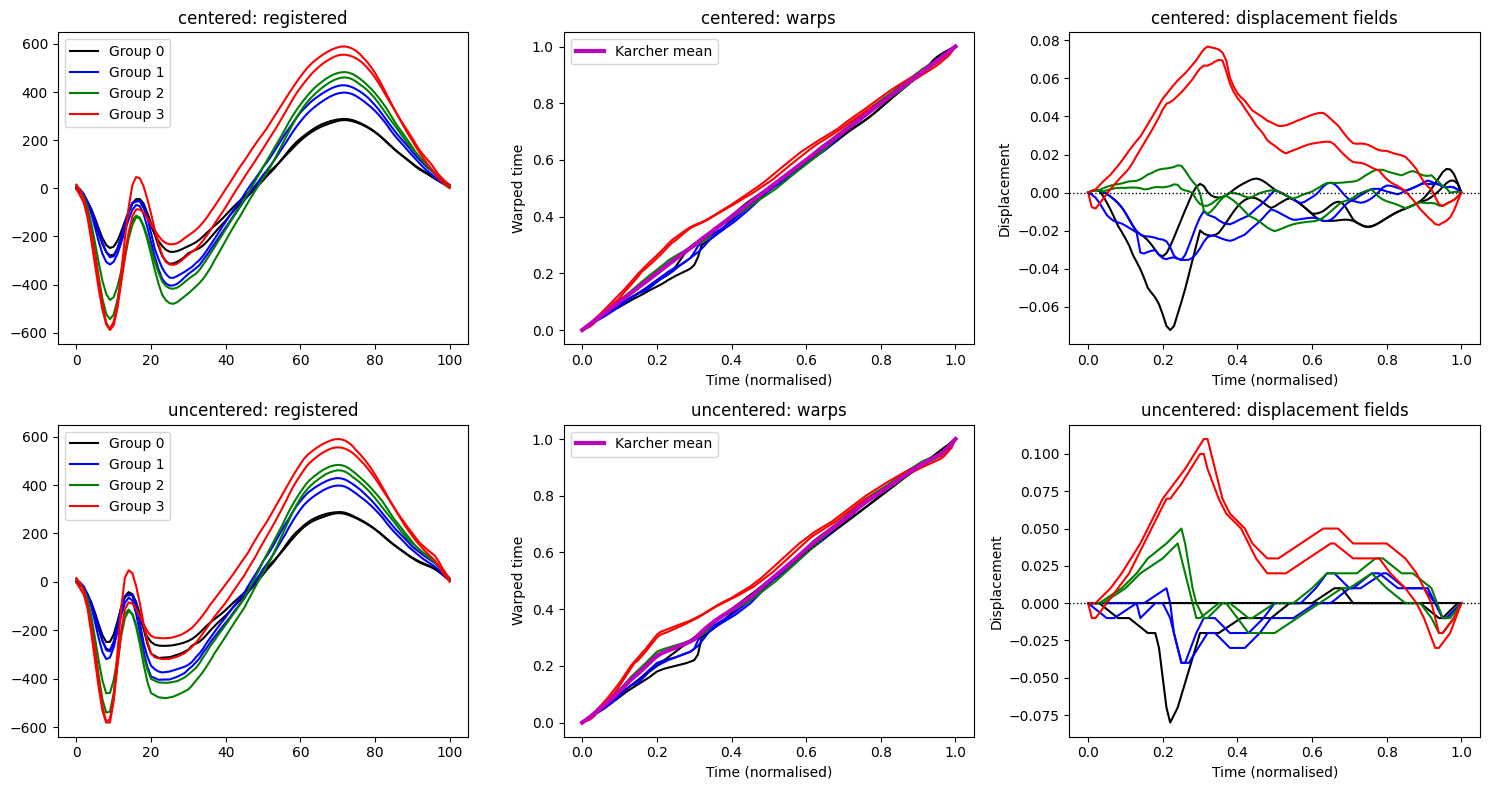

mean displacement (normalised time), centered  : 0.0096
mean displacement (normalised time), uncentered: 0.0207


In [3]:
r_c  = reg1d.register_srsf(yi, max_iter=5, center=True)
r_u  = reg1d.register_srsf(yi, max_iter=5, center=False)
fig,AX = plt.subplots(2, 3, figsize=(15,8))
for row,(r,name) in enumerate([(r_c,'centered'),(r_u,'uncentered')]):
    reg1d.plot.plot_curves(r.y, group=speed, ax=AX[row,0], colors=colors, x='percent'); AX[row,0].set_title(f'{name}: registered')
    r.warps.plot(ax=AX[row,1], group=speed, colors=colors, legend=False); AX[row,1].plot(t, r.warps.mean().w, 'm', lw=3, label='Karcher mean'); AX[row,1].legend(); AX[row,1].set_title(f'{name}: warps')
    reg1d.plot.plot_displacement_fields(r.warps.asarray(), group=speed, ax=AX[row,2], colors=colors, legend=False); AX[row,2].set_title(f'{name}: displacement fields')
plt.tight_layout(); plt.show()
print('mean displacement (normalised time), centered  :', np.abs(r_c.displacement_fields.mean(axis=0)).max().round(4))
print('mean displacement (normalised time), uncentered:', np.abs(r_u.displacement_fields.mean(axis=0)).max().round(4))

### 2. Why it matters: hypothesis tests on displacement fields

A two-sample test on displacement fields (the nlreg1d timing test) compares group means of
d_i(t). A common warp η adds (approximately) the same displacement to every observation, so a
*difference* between groups is nearly invariant to centering — but the individual displacement
fields, their pooled variance estimate near the boundaries, and any one-sample test (e.g. "is
this group's timing different from linear time?") are not. Centering makes the reference the
average timing of the sample, which is the only choice that does not depend on an arbitrary
observation.

In [4]:
from reg1d import stats
groupAB = np.where(speed <= 1, 0, 1)         # slow (0,1) vs fast (2,3)
for r,name in [(r_c,'centered'),(r_u,'uncentered')]:
    d  = r.displacement_fields
    tt = stats.permutation_ttest2(d[groupAB==0], d[groupAB==1], n_perm=500, random_state=0)
    print(f'{name:11s}: max |t| = {np.abs(tt["t"]).max():.2f}, threshold = {tt["threshold"]:.2f}, p = {tt["p"]:.3f}, clusters = {tt["clusters"]}')

centered   : max |t| = 5.70, threshold = 3.56, p = 0.042, clusters = [(7, 26), (98, 99)]
uncentered : max |t| = 5.86, threshold = 3.92, p = 0.042, clusters = [(8, 19), (23, 26)]


### 3. Centering is possible only for invertible warps

Centering composes warps with the inverse of their Karcher mean, and the Karcher mean is defined
through ψ = √γ′. Both require γ′ > 0. This is where the methods differ:

| method | warps | centering |
|---|---|---|
| SRSF, continuous, sim, pairwise, bayes | strictly increasing (diffeomorphisms) | applied by default (`center=True`) |
| landmark | strictly increasing (PCHIP / linear interpolant) | implicit: the targets are the *mean landmark times*, so the average timing is preserved at the landmarks (but the Karcher mean of the warps is not exactly the identity) |
| DTW | monotone but with flat segments (γ′ = 0 on horizontal runs) unless `step_pattern='strict'` or `smooth>0` | ψ = 0 on flat segments: the Karcher mean is still computable but the inverse of a flat warp is not unique, so `register_dtw` currently returns **uncentered** warps |

In [5]:
r_lm  = reg1d.register_landmark(yi, kinds=('zero','max'))
r_dtw = reg1d.register_dtw(yi)
r_dtws= reg1d.register_dtw(yi, step_pattern='strict', smooth=0.03)
for r,name in [(r_lm,'landmark (mean targets)'),(r_dtw,'dtw (symmetric2)'),(r_dtws,'dtw strict+smooth')]:
    g  = r.warps.asarray()
    km = reg1d.warp.karcher_mean_warp(g)
    print(f'{name:26s}: max |Karcher mean - identity| = {np.abs(km - t).max():.4f}, min slope = {np.gradient(g, axis=1).min()*100:.3f}')
# centering the DTW warps after smoothing is well defined:
wc = r_dtws.warps.center()
print('dtw strict+smooth, after centering: max |Karcher mean - identity| =', np.abs(wc.mean().w - t).max().round(4))

landmark (mean targets)   : max |Karcher mean - identity| = 0.0002, min slope = 0.829
dtw (symmetric2)          : max |Karcher mean - identity| = 0.0716, min slope = 0.000
dtw strict+smooth         : max |Karcher mean - identity| = 0.0362, min slope = 0.514
dtw strict+smooth, after centering: max |Karcher mean - identity| = 0.0002


### 4. Alternatives to Karcher-mean centering

1. **Karcher mean = identity** (current default for the diffeomorphic methods). Reference =
   average timing under the Fisher–Rao geometry. Principled, method-independent, but requires
   invertible warps.
2. **Pointwise (arithmetic) mean of the warps = identity.** Simpler, works for DTW warps with
   flat segments (the arithmetic mean of monotone functions is monotone), but the arithmetic mean
   of warps is not a proper average in the warp geometry and the result depends slightly on
   whether one averages the warps or their inverses.
3. **Landmark-anchored reference**: choose η so that a chosen event (e.g. the propulsive peak)
   sits at its mean time. Interpretable for the user, but depends on a landmark choice.
4. **No centering**: registered data live on the template's time axis; simplest, but the
   reference is arbitrary and differs between methods, which complicates comparisons between
   methods (as in notebook 2) and between studies.

For a front end, option 1 as default for diffeomorphic warps, with option 2 as the fallback for
DTW (or, better, making DTW warps diffeomorphic first via `step_pattern='strict'` and `smooth`),
and option 3 offered as an explicit user choice, seems the most defensible combination; but the
decision affects every displacement-field statistic downstream and is left open here.

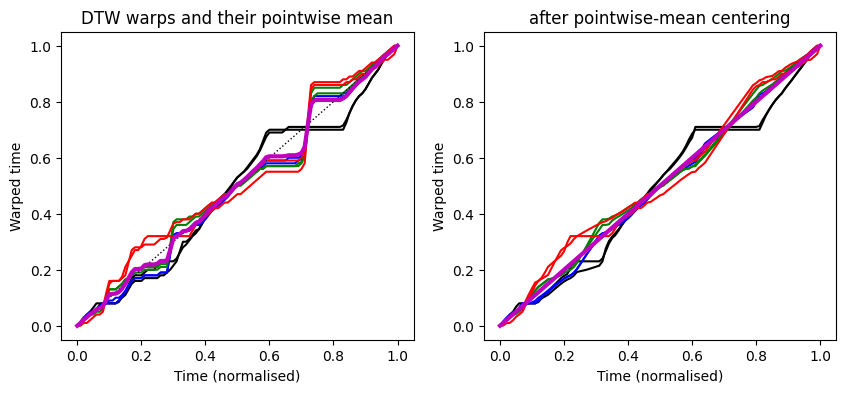

In [6]:
# option 2 for the raw DTW warps: pointwise-mean centering (illustration only)
g    = r_dtw.warps.asarray()
gbar = g.mean(axis=0)
g2   = np.array([np.interp(reg1d.warp.invert(gbar), t, gg) for gg in g])     # gamma_i o gbar^{-1}
fig,AX = plt.subplots(1, 2, figsize=(10,4))
reg1d.plot.plot_warps(g, group=speed, ax=AX[0], colors=colors, legend=False); AX[0].plot(t, gbar, 'm', lw=3); AX[0].set_title('DTW warps and their pointwise mean')
reg1d.plot.plot_warps(g2, group=speed, ax=AX[1], colors=colors, legend=False); AX[1].plot(t, g2.mean(axis=0), 'm', lw=3); AX[1].set_title('after pointwise-mean centering')
plt.show()